In [28]:
%pylab inline

import anacal
import numpy as np
import matplotlib.pylab as plt

import lsst.geom as geom
from numpy.lib import recfunctions as rfn
from astropy.visualization import simple_norm

from lsst.skymap.ringsSkyMap import (
    RingsSkyMap, RingsSkyMapConfig
)
from xlens.simulator.catalog import (
    CatalogShearTask,
    CatalogShearTaskConfig,
)
from xlens.simulator.sim import (
    MultibandSimConfig, MultibandSimTask
)

%pylab is deprecated, use %matplotlib inline and import the required libraries.
Populating the interactive namespace from numpy and matplotlib


/gpfs/mnt/gpfs02/astro/workarea/xli6/superonionSDCC/miniconda3/envs/image/lib/python3.11/site-packages/IPython/core/magics/pylab.py:166: UserWarning: pylab import has clobbered these variables: ['det', 'plt']
`%matplotlib` prevents importing * from pylab and numpy
  warn("pylab import has clobbered these variables: %s"  % clobbered +


In [36]:
config = RingsSkyMapConfig()
config.patchInnerDimensions = [501, 501]
config.tractOverlap = 0.0
config.patchBorder = 0        # pixels
config.numRings = 7000
config.pixelScale = 0.2
config.projection = "TAN"
skymap = RingsSkyMap(config=config)

config = CatalogShearTaskConfig()
config.extend_ratio = 0.92
config.kappa_value = 0.0000
config.test_value = 0.02
config.layout="grid"
config.test_target="g2"
cattask = CatalogShearTask(config=config)
truth = cattask.run(
    tract_info=skymap[0],
    seed=0,
).truthCatalog

In [37]:
config = MultibandSimConfig()
config.survey_name = (
    "lsst" 
)
config.force_isotropic=True
simtask = MultibandSimTask(config=config)
outcome = simtask.run(
    tract_info=skymap[0],
    patch_id=0,
    band="i",
    seed=0,
    truthCatalog=truth,
)

In [38]:
gal_array = np.asarray(
    outcome.simExposure.getMaskedImage().getImage().array,
    np.float64,
)
lsst_psf = outcome.simExposure.getPsf()
psf_array = np.asarray(
    anacal.utils.resize_array(
        lsst_psf.computeImage(
            geom.Point2D(250, 250)
        ).getArray(), (64, 64)
    ),
    dtype=np.float64,
)

Text(0.5, 1.0, 'PSF')

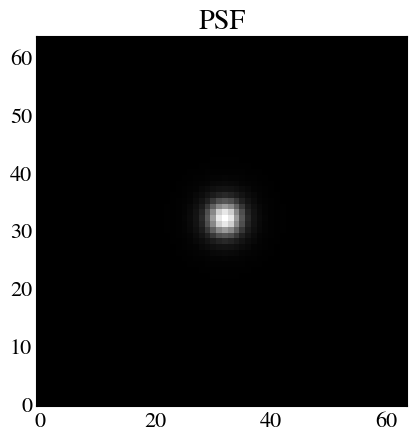

In [39]:
plt.close()
# Display the PSF image simulation
plt.imshow(psf_array, cmap="Greys_r", origin="lower")
plt.title("PSF")

# FPFS

In [ ]:
noise_variance = 0.24
fpfs_c0 = 8.4
mag_zero = 30.0
pixel_scale = 0.2

fpfs_peaks_dtype = np.dtype([("y", np.float64), ("x", np.float64)])
det = np.zeros(len(truth), dtype=fpfs_peaks_dtype)
wcs = skymap[0].getWcs()
det["x"], det["y"] = wcs.skyToPixelArray(truth["ra"], truth["dec"], degrees=True)

fpfs_config = anacal.fpfs.FpfsConfig(
    sigma_shapelets1=0.52,
)
out = anacal.fpfs.process_image(
    fpfs_config=fpfs_config,
    pixel_scale=pixel_scale,
    mag_zero=mag_zero,
    noise_variance=noise_variance,
    gal_array=gal_array,
    psf_array=psf_array,  
    mask_array=None,
    noise_array=None,
    detection=det,
    do_compute_detect_weight=False,
)

Text(0.5, 1.0, 'Exposure')

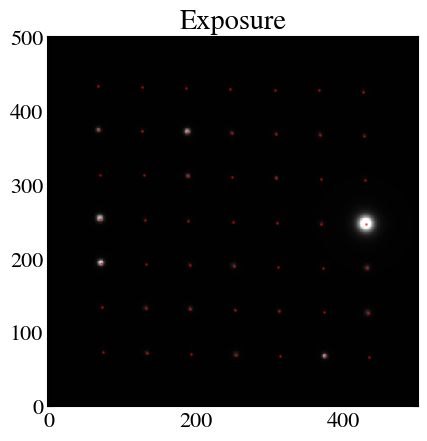

In [41]:
plt.scatter(det["x"], det["y"], marker="o", alpha=0.5, s=1.0, color="red")
plt.imshow(
    gal_array,
    aspect="equal",
    cmap="Greys_r",
    origin="lower",
    interpolation="None",
    norm=simple_norm(gal_array, "asinh", asinh_a=0.2, min_cut=-0.1, max_cut=30),
)
plt.title("Exposure")

In [52]:
assert np.abs(np.sum(out["fpfs1_e1"]) / np.sum(out["fpfs1_de1_dg1"])) < 1e-4

In [53]:
assert np.abs((np.sum(out["fpfs1_e2"]) / np.sum(out["fpfs1_de2_dg2"]) + 0.02) / 0.02) < 0.003

In [54]:
out.dtype.names

('fpfs1_e1',
 'fpfs1_de1_dg1',
 'fpfs1_de1_dg2',
 'fpfs1_e2',
 'fpfs1_de2_dg1',
 'fpfs1_de2_dg2',
 'fpfs1_q1',
 'fpfs1_dq1_dg1',
 'fpfs1_dq1_dg2',
 'fpfs1_q2',
 'fpfs1_dq2_dg1',
 'fpfs1_dq2_dg2',
 'fpfs1_m00',
 'fpfs1_dm00_dg1',
 'fpfs1_dm00_dg2',
 'fpfs1_m20',
 'fpfs1_dm20_dg1',
 'fpfs1_dm20_dg2',
 'fpfs1_m22c',
 'fpfs1_dm22c_dg1',
 'fpfs1_dm22c_dg2',
 'fpfs1_m22s',
 'fpfs1_dm22s_dg1',
 'fpfs1_dm22s_dg2',
 'fpfs1_m42c',
 'fpfs1_dm42c_dg1',
 'fpfs1_dm42c_dg2',
 'fpfs1_m42s',
 'fpfs1_dm42s_dg1',
 'fpfs1_dm42s_dg2')